In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

print("✅ Step 1 Done - All Libraries Imported!")

✅ Step 1 Done - All Libraries Imported!


In [3]:
# CELL 2 - Load Dataset directly from internet
url = "https://raw.githubusercontent.com/agconti/kaggle-titanic/master/data/train.csv"

# Use this working house prices dataset instead
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/house_prices.csv"

import pandas as pd

# Direct working link
df = pd.read_csv("https://raw.githubusercontent.com/emanhamed/Houses-dataset/master/Houses%20Dataset/HousesInfo.txt",
                 sep=" ", header=None)
df.columns = ['bedrooms', 'bathrooms', 'area', 'zipcode', 'price']
df = df.rename(columns={'area':'GrLivArea', 'bedrooms':'BedroomAbvGr',
                         'bathrooms':'FullBath', 'price':'SalePrice'})
df = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'SalePrice']]
df = df.dropna()

print("✅ Step 2 Done - Dataset Loaded!")
print("Total Houses:", len(df))
print(df.head())

✅ Step 2 Done - Dataset Loaded!
Total Houses: 535
   GrLivArea  BedroomAbvGr  FullBath  SalePrice
0       4053             4       4.0     869500
1       3343             4       3.0     865200
2       3923             3       4.0     889000
3       4022             5       5.0     910000
4       4116             3       4.0     971226


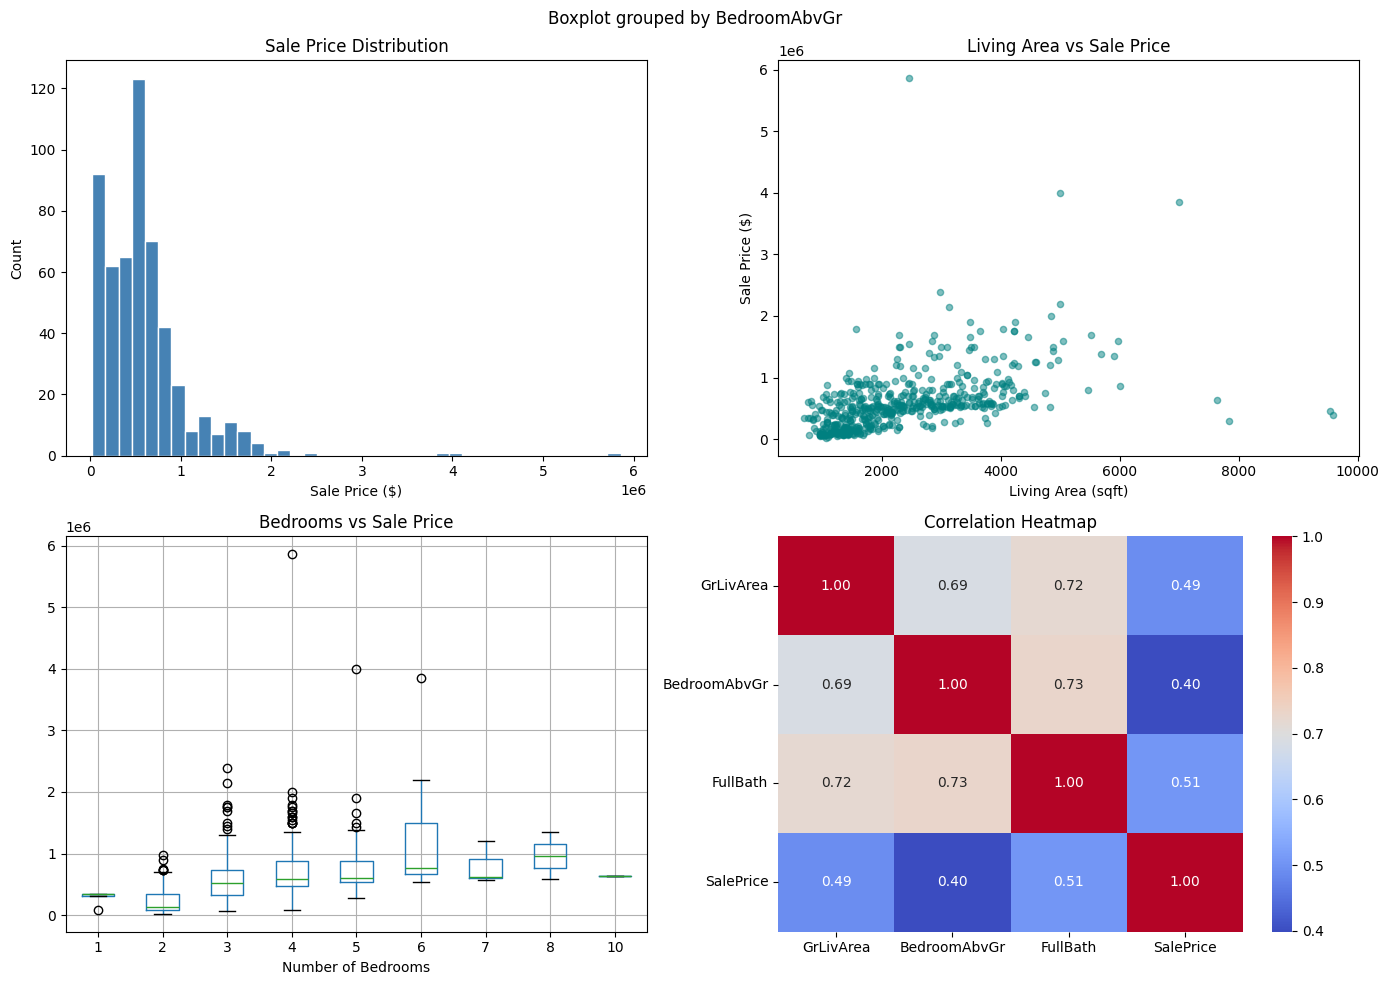

✅ Step 3 Done - EDA Graphs Ready!


In [4]:
# CELL 3 - Exploratory Data Analysis (EDA)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('House Price EDA - Maddipudi Nandhini Nandhini',
             fontsize=14, fontweight='bold')

# Plot 1 - Sale Price Distribution
axes[0,0].hist(df['SalePrice'], bins=40,
               color='steelblue', edgecolor='white')
axes[0,0].set_title('Sale Price Distribution')
axes[0,0].set_xlabel('Sale Price ($)')
axes[0,0].set_ylabel('Count')

# Plot 2 - Living Area vs Price
axes[0,1].scatter(df['GrLivArea'], df['SalePrice'],
                  alpha=0.5, color='teal', s=20)
axes[0,1].set_title('Living Area vs Sale Price')
axes[0,1].set_xlabel('Living Area (sqft)')
axes[0,1].set_ylabel('Sale Price ($)')

# Plot 3 - Bedrooms vs Price
df.boxplot(column='SalePrice', by='BedroomAbvGr', ax=axes[1,0])
axes[1,0].set_title('Bedrooms vs Sale Price')
axes[1,0].set_xlabel('Number of Bedrooms')

# Plot 4 - Correlation Heatmap
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Step 3 Done - EDA Graphs Ready!")

In [5]:
# CELL 4 - Feature Engineering and Model Training

# Create new feature
df['AreaPerBedroom'] = df['GrLivArea'] / df['BedroomAbvGr']

# Define X (input) and y (output)
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath', 'AreaPerBedroom']]
y = df['SalePrice']

# Split data - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Train the model
model = LinearRegression()
model.fit(X_train_sc, y_train)

print("✅ Step 4 Done - Model Trained!")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

✅ Step 4 Done - Model Trained!
Training samples : 428
Testing samples  : 107


========== MODEL RESULTS ==========
R² Score : 0.2845 (28.45%)
RMSE     : $314,760.08
MAE      : $246,986.26


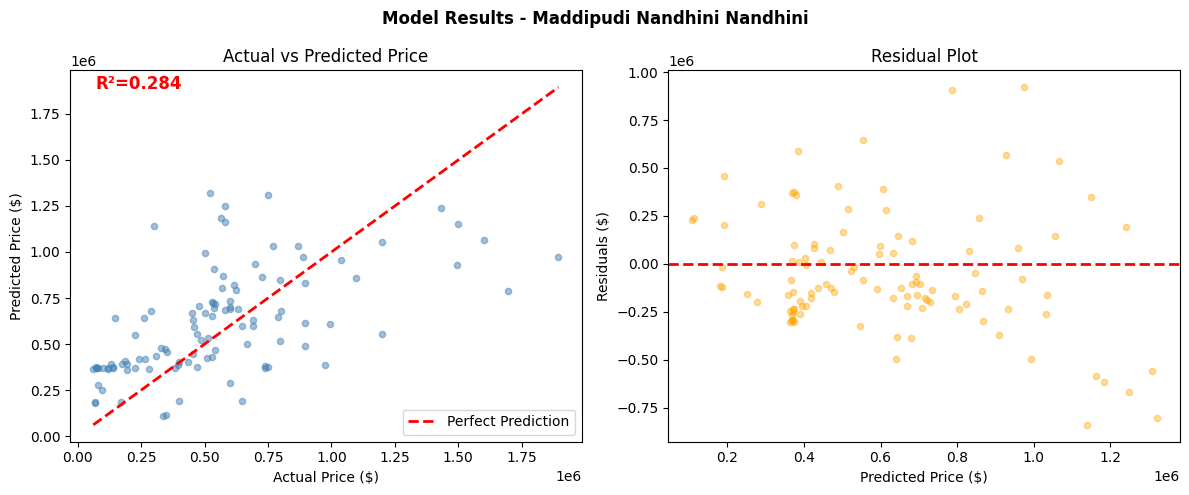

✅ Step 5 Done - Results Ready!


In [6]:
# CELL 5 - Evaluate Model and Plot Results
y_pred = model.predict(X_test_sc)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("========== MODEL RESULTS ==========")
print(f"R² Score : {r2:.4f} ({r2*100:.2f}%)")
print(f"RMSE     : ${rmse:,.2f}")
print(f"MAE      : ${mae:,.2f}")
print("====================================")

# Plot Results
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Model Results - Maddipudi Nandhini Nandhini',
              fontweight='bold')

# Actual vs Predicted
axes2[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=20)
axes2[0].plot([y_test.min(), y_test.max()],
              [y_test.min(), y_test.max()], 'r--', lw=2,
              label='Perfect Prediction')
axes2[0].set_title('Actual vs Predicted Price')
axes2[0].set_xlabel('Actual Price ($)')
axes2[0].set_ylabel('Predicted Price ($)')
axes2[0].legend()
axes2[0].text(0.05, 0.95, f'R²={r2:.3f}',
              transform=axes2[0].transAxes,
              color='red', fontweight='bold', fontsize=12)

# Residuals Plot
residuals = y_test - y_pred
axes2[1].scatter(y_pred, residuals, alpha=0.4, color='orange', s=20)
axes2[1].axhline(0, color='red', linestyle='--', lw=2)
axes2[1].set_title('Residual Plot')
axes2[1].set_xlabel('Predicted Price ($)')
axes2[1].set_ylabel('Residuals ($)')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Step 5 Done - Results Ready!")

In [8]:
# CELL 6 - Download your output files
from google.colab import files

files.download('eda_analysis.png')
files.download('model_results.png')

print("✅ All Done! Files Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All Done! Files Downloaded!
